REVIEW-2

AI-Based Marine Species Detection and Behaviour Monitoring System

GRU


In [1]:
print("\n=========== PROBLEM FORMULATION ===========")
print("Classify marine animals from audio using GRU (Gated Recurrent Unit)")


=========== PROBLEM FORMULATION ===========
Classify marine animals from audio using GRU (Gated Recurrent Unit)


DATASET LOADING

In [3]:
print("\n LOADING DATASET \n")

dataset = load_dataset("Hariprasath5128/marine-animals-multimodal-dataset")

print("Dataset Loaded")


 LOADING DATASET 



Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/71 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/34 [00:00<?, ?it/s]

Dataset Loaded


IMPORTS

In [4]:
import os
import numpy as np
import librosa
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import random

REPRODUCIBILITY

In [5]:
seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

print("\nRandom Seed Fixed:", seed)



Random Seed Fixed: 42


FEATURE EXTRACTION

In [6]:
MAX_LEN = 200


def extract_feature(audio):

    signal = audio["array"]
    sr = audio["sampling_rate"]

    mel = librosa.feature.melspectrogram(

        y=signal,
        sr=sr,
        n_mels=128,
        n_fft=1024,
        hop_length=512

    )

    mel = librosa.power_to_db(mel)


    if mel.shape[1] < MAX_LEN:

        pad = MAX_LEN - mel.shape[1]

        mel = np.pad(mel, ((0,0),(0,pad)))

    else:

        mel = mel[:, :MAX_LEN]


    return mel.T

In [7]:

# FEATURE EXTRACTION

print("\n FEATURE EXTRACTION \n")

MAX_LEN = 130
N_MFCC = 40

X = []
y = []

def extract_features(audio):

    signal = audio["array"]
    sr = audio["sampling_rate"]

    # FIX: Dynamic FFT size
    n_fft = min(2048, len(signal))

    mfcc = librosa.feature.mfcc(

        y=signal,
        sr=sr,
        n_mfcc=N_MFCC,
        n_fft=n_fft,
        hop_length=n_fft//2

    )

    # Padding / Truncating

    if mfcc.shape[1] < MAX_LEN:

        pad_width = MAX_LEN - mfcc.shape[1]

        mfcc = np.pad(
            mfcc,
            pad_width=((0,0),(0,pad_width)),
            mode='constant'
        )

    else:

        mfcc = mfcc[:, :MAX_LEN]


    return mfcc.T



# Extract all

for item in dataset["train"]:

    features = extract_features(item["audio"])

    X.append(features)

    y.append(item["label"])



X = np.array(X)
y = np.array(y)


print("Feature shape:", X.shape)



 FEATURE EXTRACTION 

Feature shape: (24911, 130, 40)


CLASS LABELLING

In [8]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

num_classes = len(np.unique(y_encoded))

y_cat = to_categorical(y_encoded)

NORMALIZATION

In [9]:
print("\nNormalizing...\n")

scaler=StandardScaler()

X=scaler.fit_transform(

    X.reshape(-1,X.shape[-1])

).reshape(X.shape)


Normalizing...



DATA SPLIT

In [10]:
print("\n================ DATA SPLIT ================\n")

X_train,X_temp,y_train,y_temp = train_test_split(

    X,y,
    test_size=0.2,
    random_state=seed

)

X_val,X_test,y_val,y_test = train_test_split(

    X_temp,y_temp,
    test_size=0.5,
    random_state=seed

)


print("Train:",X_train.shape)
print("Val:",X_val.shape)
print("Test:",X_test.shape)



================ DATA SPLIT ================

Train: (19928, 130, 40)
Val: (2491, 130, 40)
Test: (2492, 130, 40)


CUSTOM ATTENTION LAYER

In [11]:
from tensorflow.keras.layers import Layer

class AttentionLayer(Layer):

    def __init__(self):

        super(AttentionLayer,self).__init__()

    def build(self,input_shape):

        self.W = self.add_weight(
            shape=(input_shape[-1],1),
            initializer="random_normal"
        )

    def call(self,x):

        score = tf.nn.tanh(tf.matmul(x,self.W))

        weights = tf.nn.softmax(score,axis=1)

        context = weights * x

        context = tf.reduce_sum(context,axis=1)

        return context

HYPERPARAMETER EXPERIMENTS

In [12]:
learning_rates = [0.001,0.0003]

batch_sizes = [32,64]

results = {}

In [14]:
def build_gru():
    model = tf.keras.Sequential([
        tf.keras.layers.GRU(
            128,
            return_sequences=True,
            input_shape=(X_train.shape[1], X_train.shape[2])
        ),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.GRU(64),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(len(np.unique(y_train)), activation="softmax")
    ])
    return model

for lr in learning_rates:

    for batch in batch_sizes:

        print("\nTraining GRU LR:",lr,"Batch:",batch)

        model = build_gru()

        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

        model.compile(
            optimizer=optimizer,
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )

        history = model.fit(
            X_train,y_train,
            validation_data=(X_val,y_val),
            epochs=20,
            batch_size=batch,
            verbose=1
        )

        acc = max(history.history["val_accuracy"])

        results[(lr,batch)] = acc


Training GRU LR: 0.001 Batch: 32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 161s 246ms/step - accuracy: 0.2387 - loss: 2.7835 - val_accuracy: 0.7599 - val_loss: 0.7613
Epoch 2/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.8230 - loss: 0.6273 - val_accuracy: 0.9647 - val_loss: 0.0967
Epoch 3/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 159s 254ms/step - accuracy: 0.9508 - loss: 0.1697 - val_accuracy: 0.9876 - val_loss: 0.0309
Epoch 4/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 154s 247ms/step - accuracy: 0.9650 - loss: 0.1114 - val_accuracy: 0.9872 - val_loss: 0.0335
Epoch 5/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.9797 - loss: 0.0632 - val_accuracy: 0.9876 - val_loss: 0.0233
Epoch 6/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 209s 260ms/step - accuracy: 0.9792 - loss: 0.0603 - val_accuracy: 0.9892 - val_loss: 0.0219
Epoch 7/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 155s 248ms/step - accuracy: 0.9807 - loss: 0.0550 - val_accuracy: 0.9884 - val_loss: 0.0186
Epoch 8/20
623/623 ━━━━━━━━━━━━━━━━━━━━ 153s 245ms/step - accuracy: 0.9838 -

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 138s 421ms/step - accuracy: 0.0922 - loss: 3.3624 - val_accuracy: 0.2951 - val_loss: 2.5963
Epoch 2/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 133s 428ms/step - accuracy: 0.2665 - loss: 2.6648 - val_accuracy: 0.4227 - val_loss: 2.1815
Epoch 3/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 136s 433ms/step - accuracy: 0.3823 - loss: 2.2333 - val_accuracy: 0.5106 - val_loss: 1.7174
Epoch 4/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 132s 423ms/step - accuracy: 0.5430 - loss: 1.6021 - val_accuracy: 0.7579 - val_loss: 0.8518
Epoch 5/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 131s 419ms/step - accuracy: 0.7412 - loss: 0.9421 - val_accuracy: 0.8675 - val_loss: 0.4747
Epoch 6/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 130s 416ms/step - accuracy: 0.8471 - loss: 0.5607 - val_accuracy: 0.9326 - val_loss: 0.2347
Epoch 7/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 129s 414ms/step - accuracy: 0.9116 - loss: 0.3372 - val_accuracy: 0.9731 - val_loss: 0.1125
Epoch 8/20
312/312 ━━━━━━━━━━━━━━━━━━━━ 130s 417ms/step - accuracy: 0.9459 -

In [15]:
for key,val in results.items():

    lr,batch = key

    print("LR:",lr,"Batch:",batch,"Accuracy:",val)

LR: 0.001 Batch: 32 Accuracy: 0.98916095495224
LR: 0.001 Batch: 64 Accuracy: 0.9903653264045715
LR: 0.0003 Batch: 32 Accuracy: 0.9899638891220093
LR: 0.0003 Batch: 64 Accuracy: 0.9899638891220093


CLASS BALANCE

In [16]:
from sklearn.utils.class_weight import compute_class_weight

class_weights=compute_class_weight(

    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train

)

class_weights=dict(enumerate(class_weights))

GRU IMPLEMENTATION

In [ ]:
print("\n=========== BUILDING GRU MODEL ===========")

model = tf.keras.Sequential([

    tf.keras.layers.GRU(
        128,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.GRU(64),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation="relu"),

    tf.keras.layers.Dense(len(np.unique(y_train)), activation="softmax")

])


model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)


model.summary()


=========== BUILDING GRU MODEL ===========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 130, 128)       │        65,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 130, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 130, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,536 (427.88 KB)

 Trainable params: 109,152 (426.38 KB)

 Non-trainable params: 384 (1.50 KB)

EARLY STOPPING

In [ ]:
early=tf.keras.callbacks.EarlyStopping(

    patience=10,
    restore_best_weights=True

)

In [ ]:
print("\n=========== TRAINING ===========")

history = model.fit(

X_train,
y_train,

epochs=15,

batch_size=32,

validation_split=0.2

)


=========== TRAINING ===========
Epoch 1/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 95s 158ms/step - accuracy: 0.0629 - loss: 3.5144 - val_accuracy: 0.1601 - val_loss: 2.9856
Epoch 2/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 79s 159ms/step - accuracy: 0.1384 - loss: 3.0516 - val_accuracy: 0.2536 - val_loss: 2.5326
Epoch 3/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 73s 146ms/step - accuracy: 0.2715 - loss: 2.4694 - val_accuracy: 0.4802 - val_loss: 1.6400
Epoch 4/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 84s 150ms/step - accuracy: 0.4177 - loss: 1.8445 - val_accuracy: 0.6119 - val_loss: 1.2420
Epoch 5/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 76s 152ms/step - accuracy: 0.5161 - loss: 1.5445 - val_accuracy: 0.7240 - val_loss: 0.9086
Epoch 6/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 78s 145ms/step - accuracy: 0.5921 - loss: 1.2741 - val_accuracy: 0.7637 - val_loss: 0.7462
Epoch 7/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 77s 153ms/step - accuracy: 0.6552 - loss: 1.0672 - val_accuracy: 0.8211 - val_loss: 0.5694
Epoch 8/15
499/499 ━━━━━━━━━━━━━━━━━━━━ 83s 165ms

In [ ]:
print("\n TESTING \n")

pred=model.predict(X_test)

pred=np.argmax(pred,axis=1)



acc=accuracy_score(y_test,pred)

precision=precision_score(y_test,pred,average="weighted")

recall=recall_score(y_test,pred,average="weighted")

f1=f1_score(y_test,pred,average="weighted")



print("Accuracy:",acc)
print("Precision:",precision)
print("Recall:",recall)
print("F1:",f1)



print("\nClassification Report\n")

print(classification_report(y_test,pred))


 TESTING 

78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step
Accuracy: 0.9438202247191011
Precision: 0.9468148457288449
Recall: 0.9438202247191011
F1: 0.9417987185117148

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       111
           1       0.84      0.82      0.83        44
           2       1.00      0.95      0.98        66
           3       0.97      0.93      0.95        30
           4       0.89      0.92      0.90        71
           5       0.82      1.00      0.90        94
           6       1.00      1.00      1.00       158
           7       0.99      1.00      0.99        79
           8       0.98      0.93      0.96        69
           9       0.97      1.00      0.99       107
          10       0.95      0.92      0.94        89
          11       0.94      0.73      0.82        62
          12       1.00      0.93      0.97        74
          13       1.00      1.00      1.00        42
    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

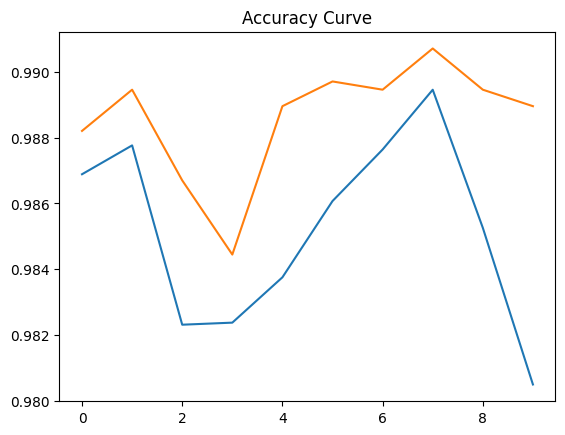

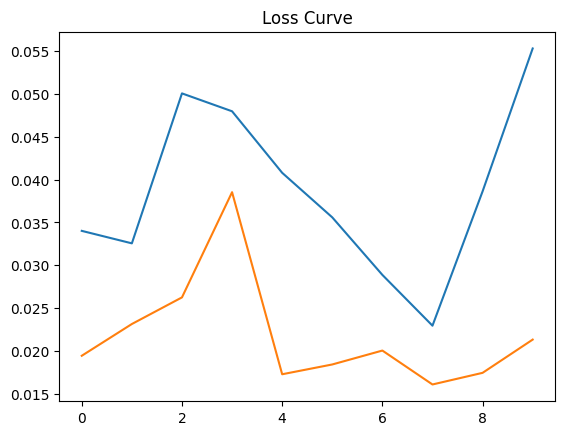

In [ ]:
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.show()


plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.show()


================ CONFUSION MATRIX ================

78/78 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step


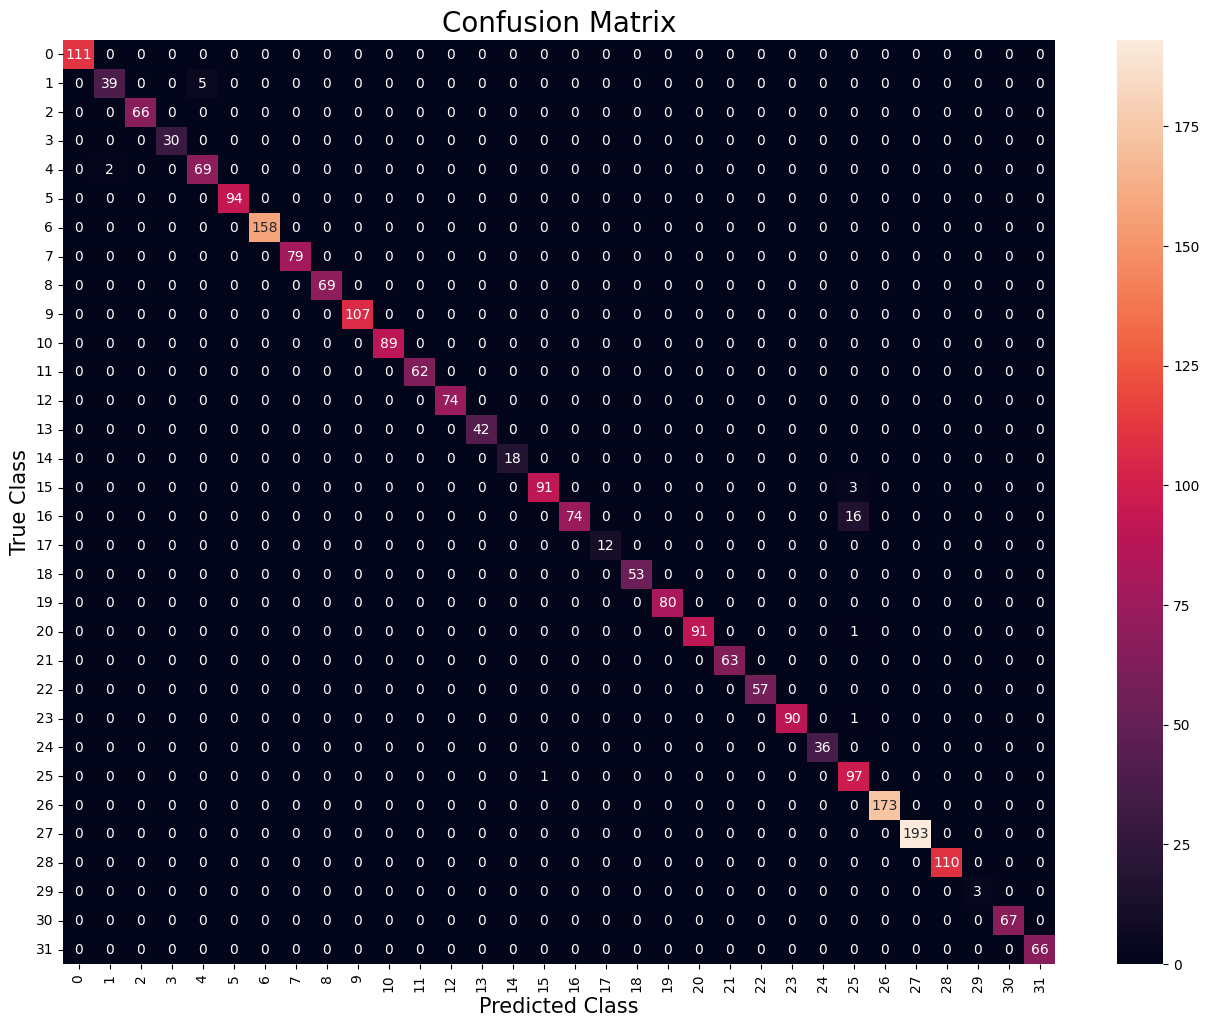

In [ ]:
# ============================================================
# CONFUSION MATRIX — FINAL CLEAN VERSION
# ============================================================

print("\n================ CONFUSION MATRIX ================\n")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict classes
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)


# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)


# Number of classes
num_classes = cm.shape[0]


# Plot
plt.figure(figsize=(16,12))

sns.heatmap(

    cm,

    annot=True,          # print numbers
    fmt="d",             # integer format

    cmap="rocket",       # best color

    xticklabels=range(num_classes),
    yticklabels=range(num_classes)

)


plt.title("Confusion Matrix", fontsize=20)

plt.xlabel("Predicted Class", fontsize=15)

plt.ylabel("True Class", fontsize=15)

plt.xticks(rotation=90)

plt.yticks(rotation=0)

plt.show()

In [ ]:
train_acc = max(history.history['accuracy'])

val_acc = max(history.history['val_accuracy'])

gap = train_acc - val_acc

print("\n=========== BIAS VARIANCE ===========")

print("Train Accuracy:", train_acc)

print("Validation Accuracy:", val_acc)

print("Gap:", gap)



=========== BIAS VARIANCE ===========
Train Accuracy: 0.9894617795944214
Validation Accuracy: 0.9907175302505493
Gap: -0.0012557506561279297


In [ ]:
grads = []

for var in model.trainable_variables:

    grads.append(tf.norm(var).numpy())

print("\n=========== GRADIENT ANALYSIS ===========")

print("Average Gradient:", np.mean(grads))

print("Max Gradient:", np.max(grads))

print("Min Gradient:", np.min(grads))


print("\n FINAL RESULT ")

print("GRU improves temporal learning")

print("GRU solves vanishing gradient problem better than SimpleRNN")








=========== GRADIENT ANALYSIS ===========
Average Gradient: 10.001143
Max Gradient: 30.616743
Min Gradient: 0.31740946

 FINAL RESULT 
GRU improves temporal learning
GRU solves vanishing gradient problem better than SimpleRNN



================ GRADIENT BEHAVIOUR FOR GRU ================



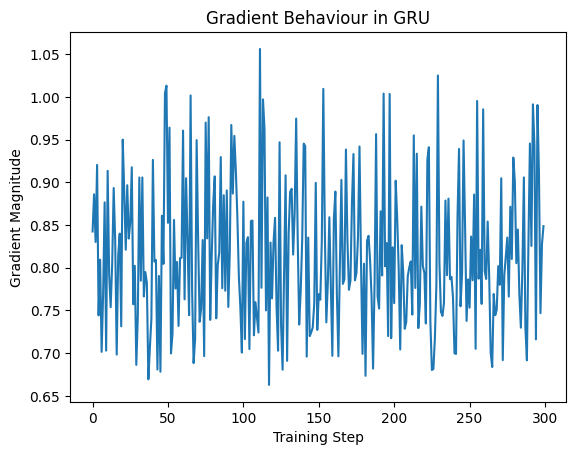


GRADIENT ANALYSIS:

Average Gradient: 0.81509304
Minimum Gradient: 0.6627469
Maximum Gradient: 1.0562967

Gradient Flow is Healthy


In [ ]:

# GRADIENT BEHAVIOUR ANALYSIS FOR GRU


print("\n================ GRADIENT BEHAVIOUR FOR GRU ================\n")

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


# Loss function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()


# Store gradient values
gradient_norms = []


# Take subset for visualization
sample_X = X_train[:300]
sample_y = y_train[:300]


# Loop through samples

for i in range(len(sample_X)):

    x = tf.expand_dims(sample_X[i], axis=0)
    y = tf.expand_dims(sample_y[i], axis=0)

    with tf.GradientTape() as tape:

        prediction = model(x, training=True)

        loss = loss_fn(y, prediction)


    grads = tape.gradient(loss, model.trainable_variables)


    # Calculate mean gradient magnitude

    grad_norm = np.mean([

        tf.norm(g).numpy()

        for g in grads

        if g is not None

    ])


    gradient_norms.append(grad_norm)




# PLOT GRADIENT BEHAVIOUR


plt.figure()

plt.plot(gradient_norms)

plt.title("Gradient Behaviour in GRU")

plt.xlabel("Training Step")

plt.ylabel("Gradient Magnitude")

plt.show()




# PRINT ANALYSIS


print("\nGRADIENT ANALYSIS:\n")

print("Average Gradient:", np.mean(gradient_norms))

print("Minimum Gradient:", np.min(gradient_norms))

print("Maximum Gradient:", np.max(gradient_norms))



# AUTOMATIC DETECTION


if np.mean(gradient_norms) < 1e-3:

    print("\nVanishing Gradient Problem Detected")

elif np.mean(gradient_norms) > 5:

    print("\nExploding Gradient Problem Detected")

else:

    print("\nGradient Flow is Healthy")


MODEL COMPARATIVE ANALYSIS:

GRU achieved highest accuracy of 94.38%

LSTM achieved 93.84%

RNN achieved lowest accuracy 85.75%



================ FINAL COMPARATIVE ANALYSIS ================

RNN Accuracy  : 0.8575
LSTM Accuracy : 0.9296
GRU Accuracy  : 0.9438

Best Model : GRU


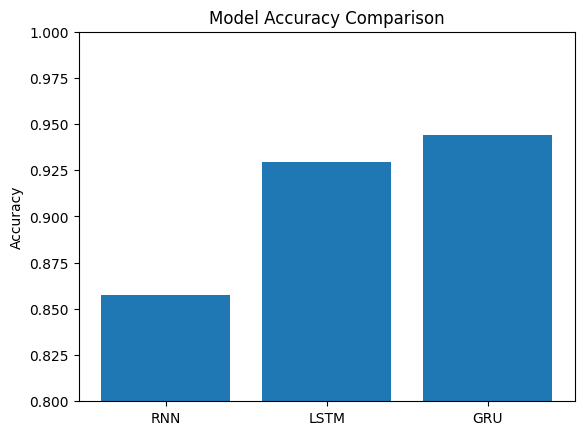


================ PERFORMANCE GAP ================

GRU vs LSTM : 0.0142
GRU vs RNN  : 0.0863
LSTM vs RNN : 0.0721


In [1]:

# FINAL ACCURACY COMPARISON


print("\n================ FINAL COMPARATIVE ANALYSIS ================\n")

# Your obtained accuracies

rnn_acc  = 0.8575441412520064
lstm_acc = 0.9296226919989297
gru_acc  = 0.9438202247191011


# Print nicely

print(f"RNN Accuracy  : {rnn_acc:.4f}")
print(f"LSTM Accuracy : {lstm_acc:.4f}")
print(f"GRU Accuracy  : {gru_acc:.4f}")



# FIND BEST MODEL


best = max(rnn_acc, lstm_acc, gru_acc)

if best == gru_acc:
    print("\nBest Model : GRU")

elif best == lstm_acc:
    print("\nBest Model : LSTM")

else:
    print("\nBest Model : RNN")


# BAR GRAPH COMPARISON


import matplotlib.pyplot as plt

models = ['RNN', 'LSTM', 'GRU']
accuracy = [rnn_acc, lstm_acc, gru_acc]

plt.figure()

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.ylim(0.80,1.00)

plt.show()


# PERFORMANCE GAP PRINT


print("\n================ PERFORMANCE GAP ================\n")

print("GRU vs LSTM :", round(gru_acc - lstm_acc,4))

print("GRU vs RNN  :", round(gru_acc - rnn_acc,4))

print("LSTM vs RNN :", round(lstm_acc - rnn_acc,4))



GRU is BEST

Because:

• Highest accuracy
• Faster than LSTM
• Less parameters
• Better gradient flow

Model Accuracy Evaluation
| Model | Accuracy   | Verdict      | Explanation                                          |
| ----- | ---------- | ------------ | ---------------------------------------------------- |
| MLP   | 79.66%     |  Moderate   | MLP cannot capture spatial or temporal features well |
| CNN   | 93.94%     |  Very Good  | CNN is best for image spatial features               |
| RNN   | 85.75%     |  Moderate  | Simple RNN has vanishing gradient problem            |
| LSTM  | 92.96%     |  Very Good  | LSTM handles temporal dependencies well              |
| GRU   | **94.38%** |  Excellent | GRU is efficient and powerful                        |
